<a href="https://colab.research.google.com/github/kukanmani06/Internship_Projects/blob/main/CNN_Brain_MRI_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import os

zip_path = '/content/brain_tumor.zip'
extract_path = '/content/brain_tumor'

# Create the directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"'{zip_path}' extracted to '{extract_path}'")


'/content/brain_tumor.zip' extracted to '/content/brain_tumor'


In [2]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np


In [6]:
from PIL import Image

# Correcting the paths to where the zip file was extracted
normal_image = Image.open("/content/brain_tumor/brain_tumor/no/1 no.jpeg")
tumor_image = Image.open("/content/brain_tumor/brain_tumor/yes/Y1.jpg")

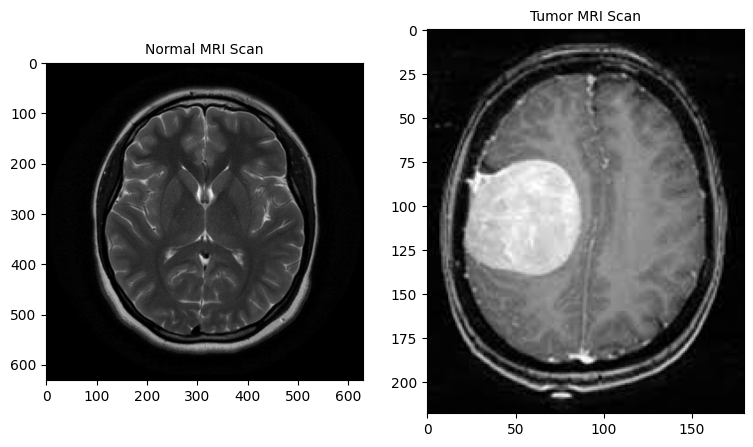

In [7]:
fig = plt.figure(figsize = (9,6))
# Add subplot (1, 2, 1) => 1 row, 2 columns, 1st Index Column
ax1 = fig.add_subplot(1, 2, 1)
img_plot = plt.imshow(normal_image, cmap = 'gray')
ax1.set_title("Normal MRI Scan", fontsize = 10)

ax2 = fig.add_subplot(1, 2, 2)
img_plot = plt.imshow(tumor_image, cmap = 'gray')
ax2.set_title("Tumor MRI Scan", fontsize = 10)
plt.show()

In [9]:
yes = os.listdir('/content/brain_tumor/brain_tumor/yes')
no = os.listdir('/content/brain_tumor/brain_tumor/no')

In [10]:
data = np.concatenate([yes, no])

In [11]:
data

array(['Y259.JPG', 'Y60.jpg', 'Y74.jpg', 'Y244.JPG', 'Y14.jpg', 'Y49.JPG',
       'Y100.JPG', 'Y36.JPG', 'Y251.JPG', 'Y95.jpg', 'Y52.jpg',
       'Y146.JPG', 'Y113.JPG', 'Y111.JPG', 'Y16.JPG', 'Y92.jpg',
       'Y71.JPG', 'Y2.jpg', 'Y67.JPG', 'Y170.JPG', 'Y248.JPG', 'Y91.jpg',
       'Y102.jpg', 'Y59.JPG', 'Y181.jpg', 'Y246.JPG', 'Y76.jpg',
       'Y79.jpg', 'Y162.jpg', 'Y22.jpg', 'Y38.jpg', 'Y70.jpg', 'Y165.JPG',
       'Y117.JPG', 'Y180.jpg', 'Y103.jpg', 'Y85.JPG', 'Y78.jpg',
       'Y193.JPG', 'Y112.JPG', 'Y166.JPG', 'Y158.JPG', 'Y12.jpg',
       'Y114.JPG', 'Y42.jpg', 'Y187.jpg', 'Y29.jpg', 'Y32.jpg', 'Y4.jpg',
       'Y184.JPG', 'Y97.JPG', 'Y98.JPG', 'Y186.jpg', 'Y55.jpg', 'Y89.JPG',
       'Y258.JPG', 'Y81.jpg', 'Y58.JPG', 'Y159.JPG', 'Y183.jpg',
       'Y31.jpg', 'Y66.JPG', 'Y194.jpg', 'Y7.jpg', 'Y15.jpg', 'Y90.jpg',
       'Y101.jpg', 'Y82.jpg', 'Y3.jpg', 'Y26.jpg', 'Y61.jpg', 'Y105.jpg',
       'Y8.jpg', 'Y167.JPG', 'Y168.jpg', 'Y245.jpg', 'Y33.jpg', 'Y20.jpg',
       'Y25.jpg

In [12]:
target_yes = np.full(len(yes), 1)
target_no = np.full(len(no), 0)

In [13]:
data_target = np.concatenate([target_yes, target_no])

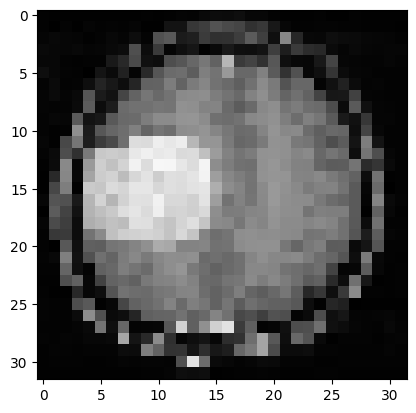

In [15]:
img = cv2.imread('/content/brain_tumor/brain_tumor/yes/Y1.jpg')
mri = cv2.resize(img, (32,32))
plt.imshow(mri)

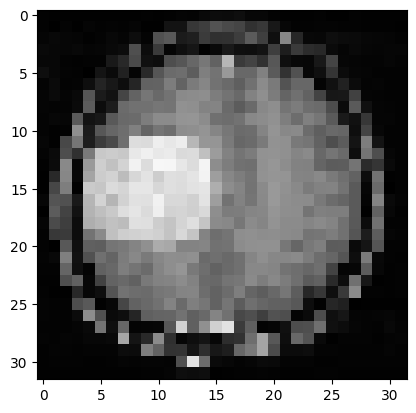

In [16]:
b, g, r = cv2.split(mri)
img = cv2.merge([r, g, b])
plt.imshow(img)

In [18]:
x_data = []

yes_dir = '/content/brain_tumor/brain_tumor/yes'
yes = os.listdir(yes_dir)

for file in yes:
    img_path = os.path.join(yes_dir, file)
    img = cv2.imread(img_path)
    if img is not None: # Check if image was loaded successfully
        mri = cv2.resize(img, (32, 32))
        b, g, r = cv2.split(mri)
        img_rgb = cv2.merge([r, g, b])
        x_data.append(img_rgb)
    else:
        print(f"Warning: Could not load image {img_path}")

In [20]:
no_dir = '/content/brain_tumor/brain_tumor/no'
no = os.listdir(no_dir)

for file in no:
    img_path = os.path.join(no_dir, file)
    img = cv2.imread(img_path)
    if img is not None: # Check if image was loaded successfully
        mri = cv2.resize(img, (32, 32))
        b, g, r = cv2.split(mri)
        img_rgb = cv2.merge([r, g, b])
        x_data.append(img_rgb)
    else:
        print(f"Warning: Could not load image {img_path}")

In [21]:
X = np.squeeze(x_data)
X.shape

(253, 32, 32, 3)

In [22]:
X = X.astype('float32')
# Normalize pixel values
X /= 255

In [23]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, data_target, test_size = 0.1, random_state = 3)

In [24]:
x_train.shape

(227, 32, 32, 3)

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

In [26]:
def build_model():
    model = Sequential()
    # filters = num of filter, kernel size = kernel matrix shape, padding = same (zero padding)
    model.add(Conv2D(filters = 16, kernel_size = (3,3), activation='relu', padding='same', input_shape = (32, 32, 3)))
    model.add(MaxPooling2D(pool_size=(2,2), strides = (2,2)))
    # dropout - To handle overfitting of model
    model.add(Dropout(0.2))

    # Conv Layer - II
    model.add(Conv2D(filters = 32, kernel_size = (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(2,2), strides = (2,2)))
    # dropout - To handle overfitting of model
    model.add(Dropout(0.2))

    # Conv Layer - III
    model.add(Conv2D(filters = 32, kernel_size = (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(2,2), strides = (2,2)))
    # dropout - To handle overfitting of model
    model.add(Dropout(0.2))

    # Flatten Connected Layer
    model.add(Flatten())

    # Dense Layer
    model.add(Dense(units = 512, activation = 'relu'))
    model.add(Dropout(0.3))
    # Binary Class - Output Layer
    model.add(Dense(units = 1, activation='sigmoid'))

    # Learning Rate
    adam_optimizer = Adam(learning_rate = 0.001)

    model.compile(optimizer = adam_optimizer, loss = 'binary_crossentropy', metrics = ['accuracy'])

    return model

In [27]:
model = build_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 277,505 (1.06 MB)

 Trainable params: 277,505 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
from keras import callbacks
filepath = "/content/drive/MyDrive/best_model.keras"
checkpoint = callbacks.ModelCheckpoint(filepath, monitor = 'val_loss', save_best_only=True,
                                       mode = 'min', verbose = 1)
callbacks_list = [checkpoint]

In [30]:
history = model.fit(x_train, y_train, epochs = 200, batch_size=32, validation_split = 0.15,
        callbacks=callbacks_list)

Epoch 1/200
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5492 - loss: 0.7070
Epoch 1: val_loss improved from None to 0.65513, saving model to /content/drive/MyDrive/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_model.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.5677 - loss: 0.6826 - val_accuracy: 0.6571 - val_loss: 0.6551
Epoch 2/200
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6186 - loss: 0.6490
Epoch 2: val_loss improved from 0.65513 to 0.61305, saving model to /content/drive/MyDrive/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_model.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5990 - loss: 0.6477 - val_accuracy: 0.6857 - val_loss: 0.6130
Epoch 3/200
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6138 - loss: 0.6223
Epoch 3: val_loss improved from 0.61305 to 0.57744, saving model to /content/drive/MyDrive/best_model.keras

Epoch 3: finished saving model to /content/driv

<Axes: >

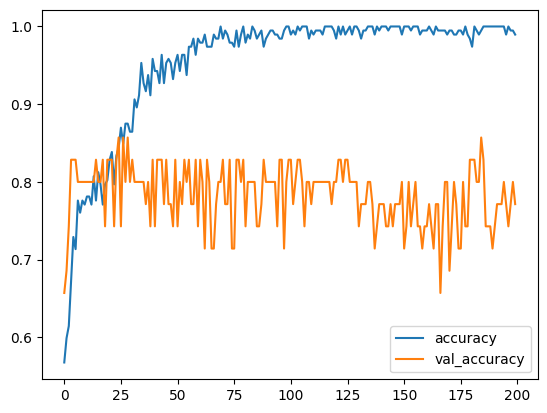

In [31]:
import pandas as pd
pd.DataFrame(history.history)[['accuracy','val_accuracy']].plot()

In [32]:
model.load_weights('/content/drive/MyDrive/best_model.keras')

In [33]:
model.evaluate(x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8077 - loss: 0.5029


[0.5028620958328247, 0.807692289352417]

In [34]:
predictions = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step


In [35]:
yhat = np.round(predictions)

In [36]:
from sklearn.metrics import confusion_matrix, classification_report
confusion_matrix(y_test, yhat)

array([[ 5,  1],
       [ 4, 16]])

In [37]:
print(classification_report(y_test, yhat))

              precision    recall  f1-score   support

           0       0.56      0.83      0.67         6
           1       0.94      0.80      0.86        20

    accuracy                           0.81        26
   macro avg       0.75      0.82      0.77        26
weighted avg       0.85      0.81      0.82        26



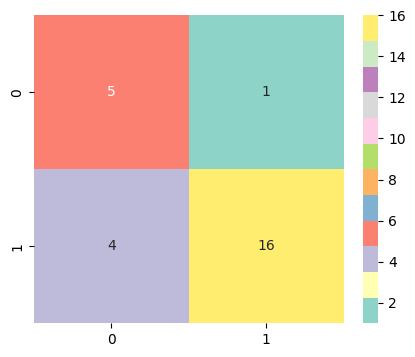

In [38]:
import seaborn as sns
plt.figure(figsize = (5,4))
sns.heatmap(confusion_matrix(y_test, yhat), annot = True, cmap = 'Set3')
plt.show()

In [39]:
x_new_data = []

img_data = cv2.imread('/content/brain_tumor/brain_tumor/yes/Y102.jpg')
mri = cv2.resize(img_data, (32, 32))
b, g, r = cv2.split(mri)
img_data = cv2.merge([r, g, b])
x_new_data.append(img_data)

In [40]:
x_new = np.squeeze(x_new_data)
x_new = x_new.astype('float32')
x_new /= 255

In [41]:
x_new = x_new.reshape(1, 32, 32, 3)

In [42]:
np.round(model.predict(x_new))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


array([[1.]], dtype=float32)

In [43]:
x_new_data = []

img_data = cv2.imread('/content/brain_tumor/brain_tumor/no/12 no.jpg')
mri = cv2.resize(img_data, (32, 32))
b, g, r = cv2.split(mri)
img_data = cv2.merge([r, g, b])
x_new_data.append(img_data)

In [44]:
x_new = np.squeeze(x_new_data)
x_new = x_new.astype('float32')
x_new /= 255

In [45]:
x_new.shape

(32, 32, 3)

In [46]:
x_new = x_new.reshape(1, 32, 32, 3)

In [47]:
np.round(model.predict(x_new))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


array([[0.]], dtype=float32)

In [48]:
model.evaluate(x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.8077 - loss: 0.5029


[0.5028620958328247, 0.807692289352417]

In [49]:
print(classification_report(y_test, yhat))

              precision    recall  f1-score   support

           0       0.56      0.83      0.67         6
           1       0.94      0.80      0.86        20

    accuracy                           0.81        26
   macro avg       0.75      0.82      0.77        26
weighted avg       0.85      0.81      0.82        26



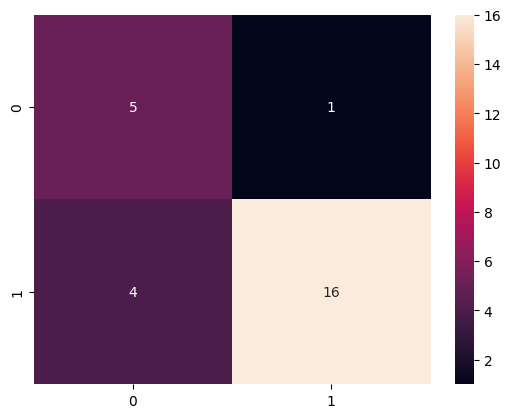

In [50]:
sns.heatmap(confusion_matrix(y_test, yhat), annot=True)
plt.show()